In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define paths
dataset_path = "./"
img_size = (128, 128)
batch_size = 32


c:\Users\vyash\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\__init__.py:169: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:

train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)


Found 5239 images belonging to 4 classes.
Found 1308 images belonging to 4 classes.


In [3]:

# Build ANN model
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(128, 128, 3)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

# Compile model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train model
model.fit(train_generator, validation_data=val_generator, epochs=10)

# Save model
model.save("cat_dog_classifier.h5")




Epoch 1/10


164/164 [==============================] - 76s 457ms/step - loss: -131158.7344 - accuracy: 0.3869 - val_loss: -547986.6250 - val_accuracy: 0.3884
Epoch 2/10
164/164 [==============================] - 25s 152ms/step - loss: -2222209.0000 - accuracy: 0.3884 - val_loss: -4900322.5000 - val_accuracy: 0.3884
Epoch 3/10
164/164 [==============================] - 24s 146ms/step - loss: -10151749.0000 - accuracy: 0.3884 - val_loss: -17106116.0000 - val_accuracy: 0.3884
Epoch 4/10
164/164 [==============================] - 25s 151ms/step - loss: -27749826.0000 - accuracy: 0.3884 - val_loss: -40786544.0000 - val_accuracy: 0.3884
Epoch 5/10
164/164 [==============================] - 28s 169ms/step - loss: -58150240.0000 - accuracy: 0.3884 - val_loss: -78266352.0000 - val_accuracy: 0.3884
Epoch 6/10
164/164 [==============================] - 26s 157ms/step - loss: -103744352.0000 - accuracy: 0.3884 - val_loss: -132396352.0000 - val_accuracy: 0.3884
Epoch 7/10
164/164 [==============

c:\Users\vyash\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [4]:
from tensorflow.keras.models import load_model
import numpy as np
from tensorflow.keras.preprocessing import image
model = load_model("cat_dog_classifier.h5")

In [15]:
img_path = "X:\CVDL\Labs\Lab 3 21-02-25\dog\dog.32.jpg"  
img = image.load_img(img_path, target_size=(128, 128))

In [16]:
import matplotlib.pyplot as plt

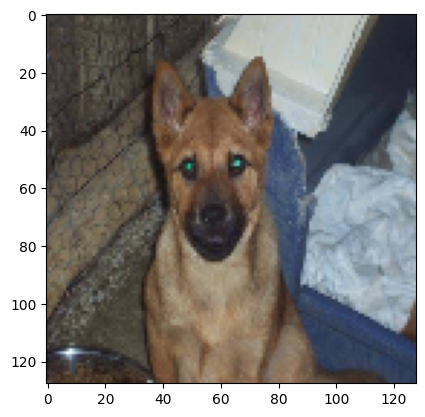

In [17]:
plt.imshow(img)

In [18]:
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) 
img_array /= 255.0  

In [19]:

prediction = model.predict(img_array)


if prediction[0][0] > 0.5:
    print("It's a Dog! 🐶")
else:
    print("It's a Cat! 🐱")


1/1 [==============================] - 0s 18ms/step
It's a Dog! 🐶
